# Exercise 05 — Polynomials, Integrals and Zeros

NUMA01 VT2026 — Arvid Brenner & Sixten Midsem

Lösningar till `exercise05.md`. Polynom som funktioner och listor, scipy
`quad` för integraler och `fsolve` för nollställen.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import fsolve


## Task 1 — Polynom $p(x) = ax^3 + bx^2 + cx + d$


In [2]:
def p1(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

print(p1(2, 1, 0, 0, 0))   # 8
print(p1(2, 1, -1, 1, -1)) # 5


8
5


## Task 2 — Koefficienter som lista (längd 4)


In [3]:
def p2(x, coeffs):
    """coeffs = [a, b, c, d] för ax^3 + bx^2 + cx + d."""
    a, b, c, d = coeffs
    return a * x**3 + b * x**2 + c * x + d

print(p2(2, [1, -1, 1, -1]))


5


## Task 3 — Packing/unpacking

Vi kan återanvända `p1` direkt med `*coeffs`-unpacking:


In [4]:
coeffs = [1, -1, 1, -1]
print(p1(2, *coeffs))           # samma som p1(2, 1, -1, 1, -1)
print(p2(2, coeffs))
assert p1(2, *coeffs) == p2(2, coeffs)


5
5


## Task 4 — Polynom av godtycklig grad

Listan `coeffs = [a_n, ..., a_1, a_0]` representerar
$p(x) = a_n x^n + \dots + a_1 x + a_0$. Horners metod är numeriskt stabil
och billig:


In [5]:
def poly(x, coeffs):
    """Evaluera polynom med Horners metod. coeffs = [a_n, ..., a_0]."""
    result = 0
    for c in coeffs:
        result = result * x + c
    return result


# Test: p(x) = x^3 - x^2 + x - 1 vid x=2 ⇒ 8 - 4 + 2 - 1 = 5
print(poly(2, [1, -1, 1, -1]))

# Konstant: p(x) = 7
print(poly(99, [7]))

# Femtegradare
print(poly(1.5, [1, 0, 0, 0, 0, -1]))   # x^5 - 1 vid 1.5
print(1.5**5 - 1)


5
7
6.59375
6.59375


## Task 5 — Integral $\int_0^{\pi/2} \sin(\omega x)\,dx$, $\omega = 2\pi$

Analytiskt: $\int_0^{\pi/2} \sin(\omega x)\,dx = (1 - \cos(\omega \pi/2))/\omega$.
För $\omega = 2\pi$: $(1 - \cos(\pi^2))/(2\pi)$.


In [6]:
omega = 2 * np.pi

val, err = quad(lambda x: np.sin(omega * x), 0, np.pi/2)
analytical = (1 - np.cos(omega * np.pi / 2)) / omega

print(f"quad:        {val:.12f}  (uppskattat fel {err:.2e})")
print(f"analytisk:   {analytical:.12f}")
print(f"|diff|:      {abs(val - analytical):.2e}")


quad:        0.302821780500  (uppskattat fel 1.09e-12)
analytisk:   0.302821780500
|diff|:      1.11e-16


## Task 6 — Integral som funktion av $\omega$


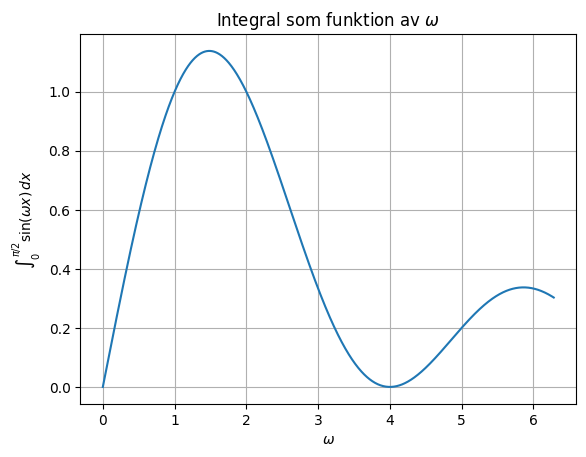

In [7]:
omegas = np.linspace(0, 2 * np.pi, 1000)
integrals = np.array([quad(lambda x, w=w: np.sin(w * x), 0, np.pi/2)[0]
                      for w in omegas])

plt.figure()
plt.plot(omegas, integrals)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\int_0^{\pi/2}\sin(\omega x)\,dx$')
plt.title(r'Integral som funktion av $\omega$')
plt.grid(True); plt.show()


## Task 7 — Positivt nollställe till $p(x) = x^2 + x - 3$

Med formelmetoden: $x = (-1 + \sqrt{13})/2 \approx 1.302776$.


In [8]:
# coeffs = [1, 1, -3] enligt poly-konventionen
roots = fsolve(lambda x: poly(x, [1, 1, -3]), x0=1.0)
print(f"fsolve:    {roots[0]:.10f}")
print(f"analytisk: {(-1 + np.sqrt(13))/2:.10f}")


fsolve:    1.3027756377
analytisk: 1.3027756377


## Task 8 — Positiva nollställen till $p_a(x) = a x^2 + x - 3$ för $a \in [1, 5]$

Analytiskt: $x_+(a) = (-1 + \sqrt{1 + 12a})/(2a)$. Inte linjärt — det är en
omvänt skalad kvadratrotsfunktion.


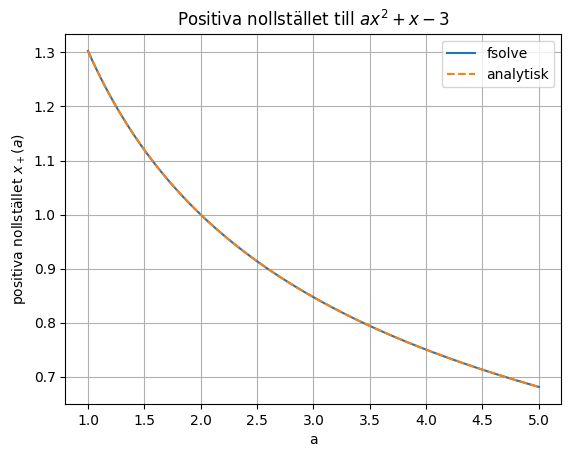

Linjärt? Nej — funktionen avtar med a som ~1/sqrt(a) för stora a.


In [9]:
a_vals = np.linspace(1, 5, 200)
zeros = np.array([fsolve(lambda x, a=a: poly(x, [a, 1, -3]), 1.0)[0]
                  for a in a_vals])
analytic = (-1 + np.sqrt(1 + 12 * a_vals)) / (2 * a_vals)

plt.figure()
plt.plot(a_vals, zeros, label='fsolve')
plt.plot(a_vals, analytic, '--', label='analytisk')
plt.xlabel('a'); plt.ylabel('positiva nollstället $x_+(a)$')
plt.title(r'Positiva nollstället till $a x^2 + x - 3$')
plt.legend(); plt.grid(True); plt.show()

print("Linjärt? Nej — funktionen avtar med a som ~1/sqrt(a) för stora a.")
